Project Planning Stage (Hong To Nhu Trinh)
- 

In [2]:
library(tidyverse)
library(repr)
library(tidymodels)
options(repr.matrix.max.rows = 6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

**1. Data Description**

**players.csv**
- Variable names: experience, hashedEmail, name, gender, played_hours, Age, subscribe
- Number of variables: 9
- Data type:
  - Character (chr): experience, hashedEmail, name, gender
  - Double (dbl): played_hours, Age
  - Logical (lgl): subscribe
- Type of variable:
  - Quantitative: played_hours, Age
  - Categorical: experience, gender, subscribe
- Mean (displayed in mean_table): 
  - played_hours: 5.85 (h)
  - Age: 21.14 (years old)
- Number of observations: 195
- Data issue: the quantitative variables contain enormous data with different values. To make it easier to graph and investigate, the variables could be separated into groups of certain value (ex: Age into age group like (5-10), (10-15),...) 
- Potential issue: ...

**sessions.csv**
- Variable names: hashedEmail, start_time, end_time, original_start_time, original_end_time 
- Number of variables: 5
- Data type:
  - Character (chr): hashedEmail, start_time, end_time
  - Double (dbl): original_start_time, original_end_time 
- Number of observations: 1534
- Potential issues: 

In [3]:
library(dplyr)
player <- read_csv("/home/jovyan/work/minecraft_project/players.csv")
mean_table <- player %>%
  summarise(
    mean_age = round(mean(Age, na.rm = TRUE),2),
    mean_played_hours = round(mean(played_hours, na.rm = TRUE),2))
mean_table
session <- read_csv("/home/jovyan/work/minecraft_project/sessions.csv")

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


mean_age,mean_played_hours
<dbl>,<dbl>
21.14,5.85


Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


**2. Questions**

**Question 1:** What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?

**Specific question:** Can age predict if players subscribe or not in player.csv?

How the data will help you address the question of interest: 

Wrangle planning: 
- Remove the columns: hashedemail, name  
- Mutate the column age and played hours into a group of certain values (shown in player_2)

**3. Exploratory Data Analysis and Visualization**

In [4]:
player_2 <- read_csv("/home/jovyan/work/minecraft_project/players.csv") |>
            mutate(age_group=cut(Age,
      breaks = c(5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
                 55, 60),
      labels = c("5-10", "11-15", "16-20", "21-25", "26-30",
                 "31-35", "36-40", "41-45", "46-50", "51-55", "56-60"),
      na.rm=TRUE)) |>
             mutate(
    playhours_group = cut(
      played_hours,
      breaks = c(0, 50, 100, 200, Inf),
      labels = c("0–50h (new)", "51–100h (casual)", "101–200h (regular)", "200h+ (hardcore)"),
      na.rm=TRUE))
player_2

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age,age_group,playhours_group
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<fct>,<fct>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,5-10,0–50h (new)
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,16-20,0–50h (new)
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17,16-20,NA
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57,56-60,NA
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17,16-20,0–50h (new)
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA,NA,0–50h (new)


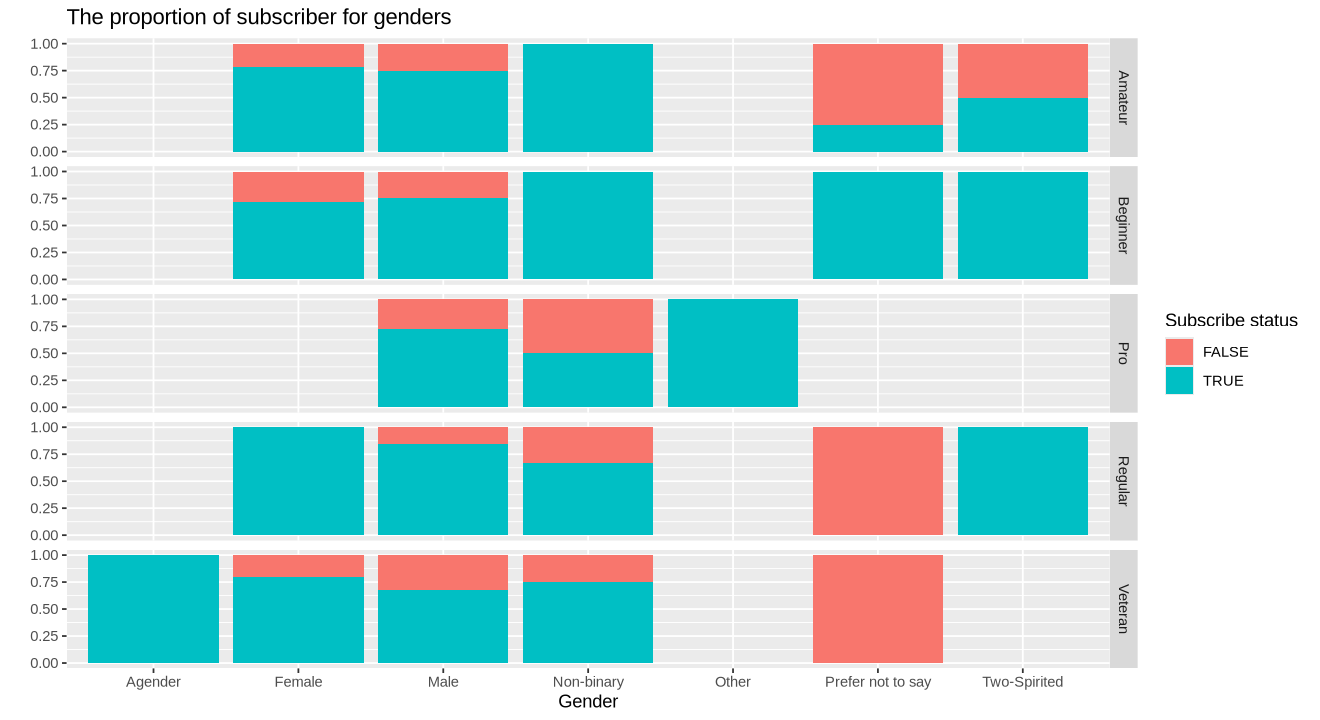

In [9]:
options(repr.plot.width = 11, repr.plot.height = 6)
player_bar_gender <- player |>
    ggplot(aes(x =gender, fill = subscribe)) + 
    geom_bar( position = 'fill') + 
    xlab("Gender") +
    ylab("") +
    labs(fill = "Subscribe status") +
    ggtitle("The proportion of subscriber for genders") +
    facet_grid(facets = vars(experience))
player_bar_gender

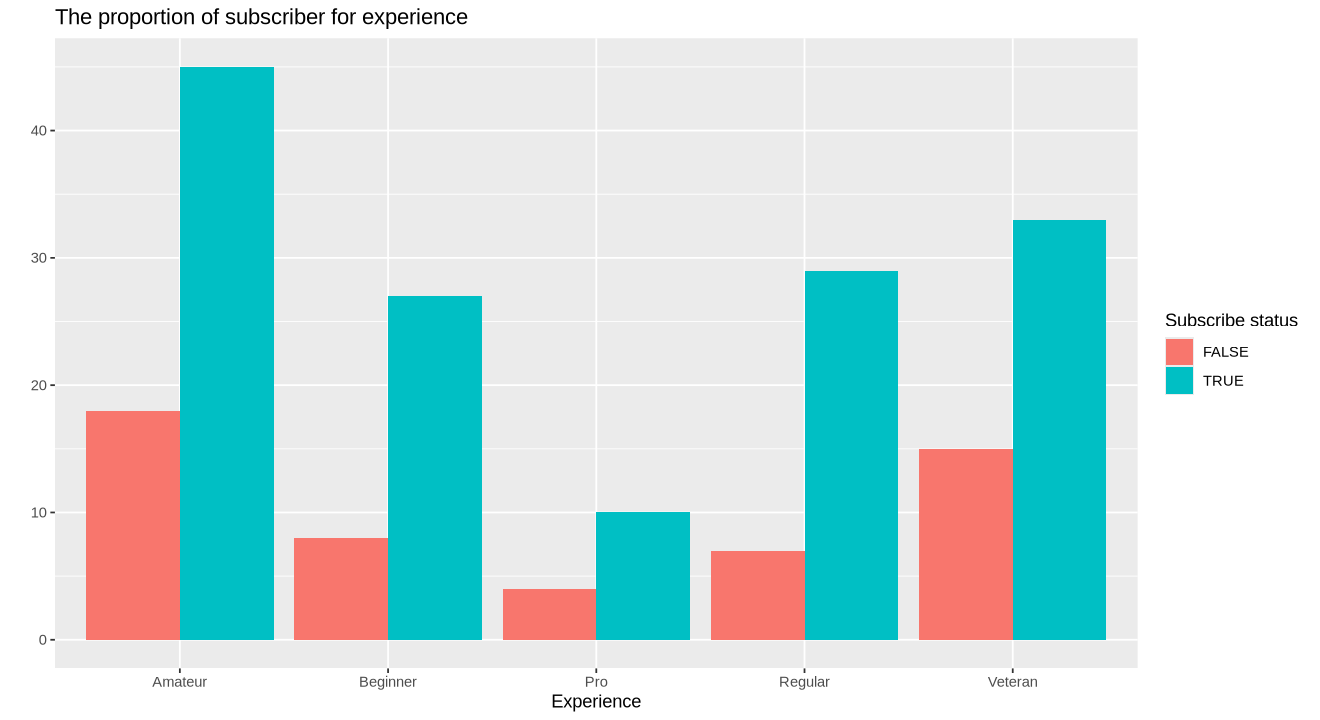

In [6]:
options(repr.plot.width = 11, repr.plot.height = 6)
player_bar_experience <- player |>
    ggplot(aes(x =experience, fill = subscribe)) + 
    geom_bar(position = 'Dodge') + 
    xlab("Experience") +
    ylab("") +
    labs(fill = "Subscribe status") +
    ggtitle("The proportion of subscriber for experience") 
player_bar_experience

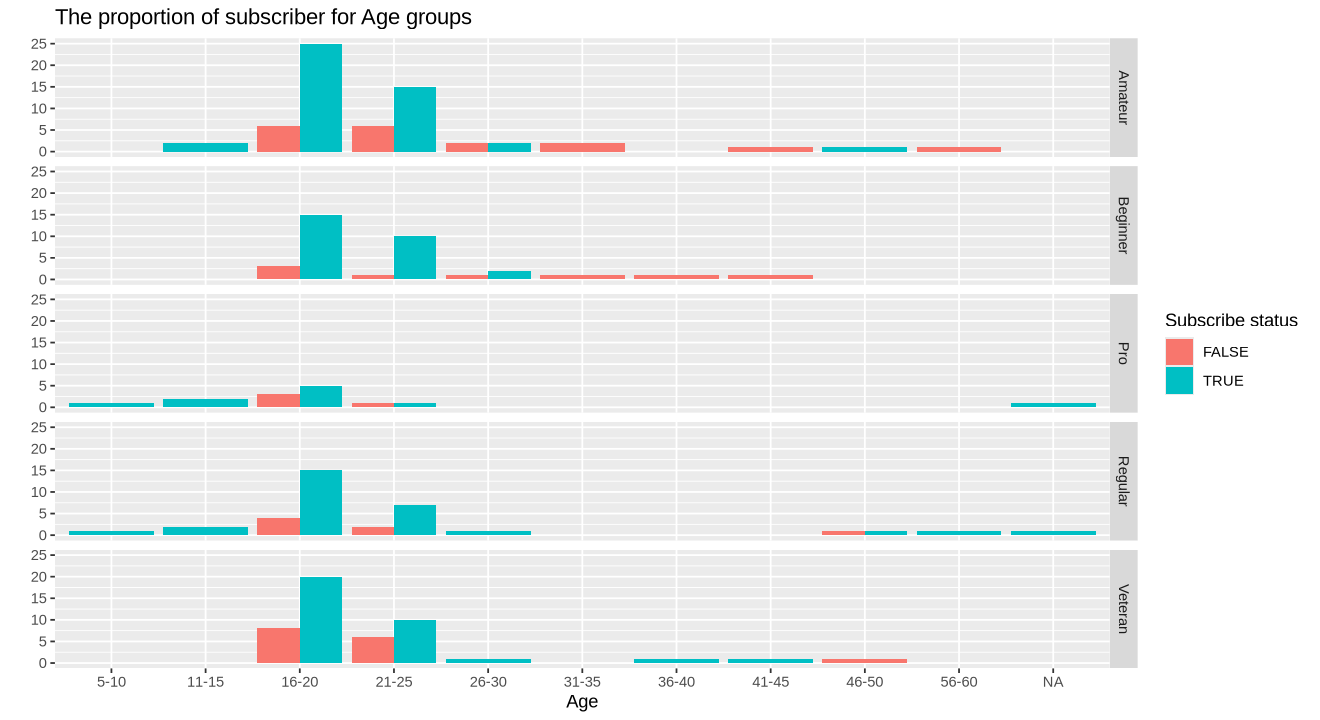

In [11]:
options(repr.plot.width = 11, repr.plot.height = 6)
player_bar_age <- player_2 |>
    ggplot(aes(x =age_group, fill = subscribe)) + 
    geom_bar(position = 'dodge') + 
    xlab("Age") +
    ylab("") +
    labs(fill = "Subscribe status") +
    ggtitle("The proportion of subscriber for Age groups") +
    facet_grid(facets = vars(experience))
player_bar_age

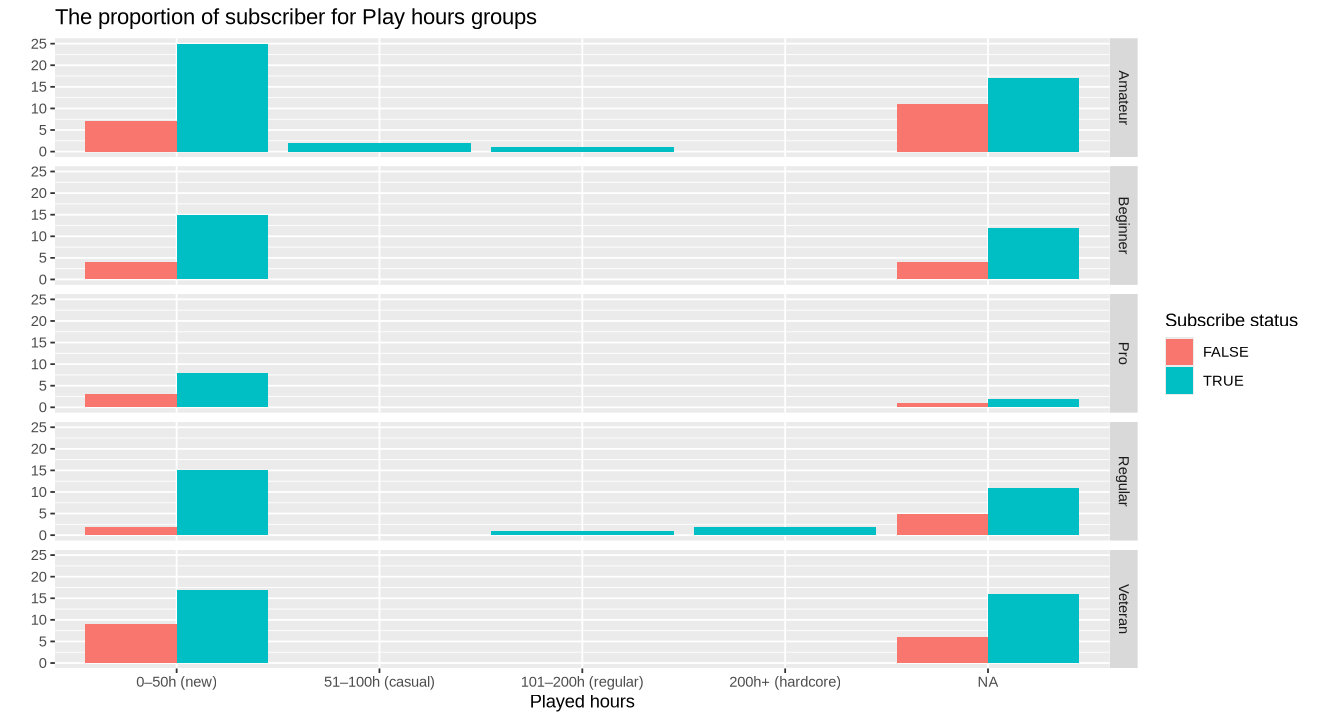

In [26]:
options(repr.plot.width = 11, repr.plot.height = 6)
player_bar_played_hours <- player |>
    ggplot(aes(x =playhours_group, fill = subscribe)) + 
    geom_bar(position = 'dodge') + 
    xlab("Played hours") +
    ylab("") +
    labs(fill = "Subscribe status") +
    ggtitle("The proportion of subscriber for Play hours groups") +
    facet_grid(facets = vars(experience))
player_bar_played_hours

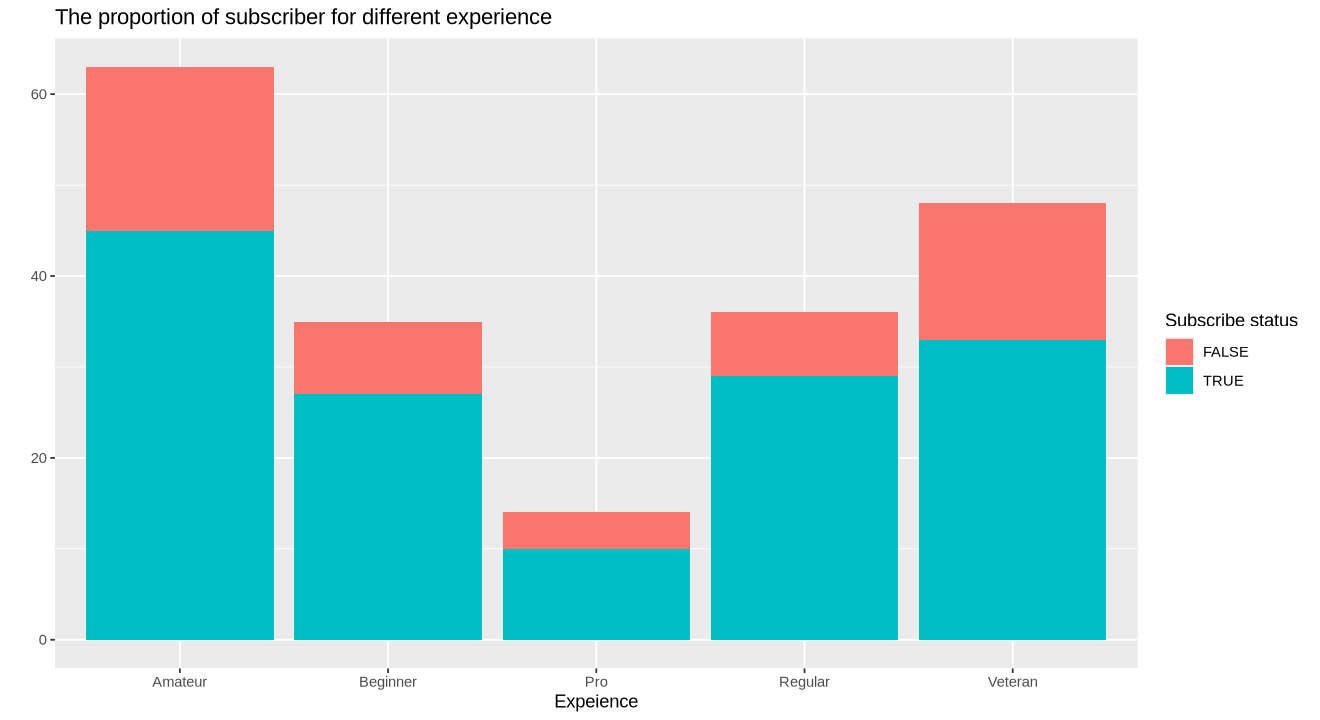

In [48]:
options(repr.plot.width = 11, repr.plot.height = 6)
player_bar_experience <- player |>
    ggplot(aes(x =experience, fill=subscribe)) + 
    geom_bar() + 
    xlab("Expeience") +
    ylab("") +
    labs(fill = "Subscribe status") +
    ggtitle("The proportion of subscriber for different experience") 
player_bar_experience